# Test different CNN architectures provided in `Landmine Detection Using Autoencoders on  Multipolarization GPR Volumetric Data` article

# Передмова
Для тесту будуть братись 3 різні архітектури згорткових мереж для 3 різних способів передачі даних

## Базові параметри що будуть спільними для всіх
- **Розмір патча (висота х ширина):** 176х32. Треба додати 6 пустих відліків до оригінальної глибини, щоб глибина ідеально ділилася на 2 під час стиснення. Вікно шириною 32 траси ковзає вздовж профілю на 440 трас із кроком 17.
- **Оптимізатор:*** Adam
- **Функція активації на виході:** `tanh` (важливо щоб всі вхідні дані були в діапазоні [-1,1])
- **Архітектури стиснення:** Для кожної з категорій нижче ми проженемо три варіанти згортки:
    - **A1:** Стиснення в 16 разів (найбільше деталей).
    - **A2:** Стиснення в 32 рази.
    - **A3:** Стиснення в 64 рази (екстримальна компресія, залишає лише загальну геометрію ґрунту).

### Тестування
Індекатором аномалії буде (Reconstruction Error) із оцінкою MSE (Mean Square Error) та MAE (Mean Absolute Error) між оригінальним патчем та тим, що згенерував декодер.

- **Етап А: Тренування (Baseline)**<br>
Моделі згодовується набір даних відповідної розмірності. На цьому етапі особлива увага приділяється лише графіку Loss. Якщо Loss падає і стабілізується на низькому рівні - модель успішно вивчила фізику ґрунту. Якщо Loss залишається високим (що ймовірно для жорсткого стиснення А3) - модель не здатна відтворити навіть фон.
- **Етап Б: Інферренс (Тест на даних із "аномаліями")**<br>
Береться тестовий В-скан **із міною** (з тієї частини датасету, на якій не проходило тренування). Пропускається ковзне вікно через цей В-скан (25 патчів). Розраховується загальний `MSE`
- **Етап В: Аналіз графіку помилок**<br>
Будується графік (вісь Х - номери патчів від 1 до 25, Y - значення помилки `MSE`).


**Найкраща модель**<br>
Найкращою архітектурою буде та, що дає найбільшу *дельту* між середньою помилкою на фонових патчах та піковою помилкою на аномальному патчі.


## Імпорти

In [49]:
import torch
from torch import nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, ConcatDataset

from models import AutoencoderA1, AutoencoderA2, train_autoencoder
from utils import run_evaluation_pipeline, plot_comparison_from_json, init_full_results_storage

In [50]:
RESULTS_FILE = "./Test1.json"
results_db = init_full_results_storage(RESULTS_FILE)

Файл ./Test1.json знайдено. Завантажуємо існуючу структуру.


# Підготовка даних

In [4]:
file_path = '../datasets/giuriati_2/20170621_deg0_HHVV.npy'
full_data = np.load(file_path, allow_pickle=True).item()
data = full_data['data']
gt = full_data['ground_truth']

print("-" * 40)
print(f"Вміст словника (ключі): {list(full_data.keys())}")
print(f"Розмірність матриці даних (Shape): {np.shape(data)}")
print(f"Розмірність розмітки (Ground Truth): {np.shape(gt)}")
print(f"Мінімальне значення: {data.min():.4f}")
print(f"Максимальне значення: {data.max():.4f}")
print("-" * 40)

----------------------------------------
Вміст словника (ключі): ['param', 'data', 'ground_truth']
Розмірність матриці даних (Shape): (66, 170, 440)
Розмірність розмітки (Ground Truth): (66,)
Мінімальне значення: -2.6768
Максимальне значення: 3.0877
----------------------------------------


In [5]:
# ==========================================
# ГЛОБАЛЬНА ПЕРЕДОБРОБКА ДАНИХ (Векторизована)
# ==========================================
alpha = 0.015

# 1. Background Removal (віднімаємо середнє по осі трас для кожної лінії)
mean_traces = np.mean(data, axis=2, keepdims=True)
bg_removed = data - mean_traces

# 2. TVG (Компенсація згасання)
depth = data.shape[1] # 170
gain_curve = np.exp(alpha * np.arange(depth)).reshape(1, depth, 1)
tvg_applied = bg_removed * gain_curve

# 3. Знаходимо max_val ТІЛЬКИ на тренувальних даних (там де немає мін)
train_indices = np.where(gt == 0)[0]
test_indices = np.where(gt == 1)[0]

# Беремо абсолютний максимум тільки з безпечних ліній
max_val = np.max(np.abs(tvg_applied[train_indices]))

# 4. Глобальна нормалізація всього масиву
normalized_data = tvg_applied / max_val

# 5. Padding (додаємо 6 відліків по осі глибини до всіх 66 ліній)
pad_width = ((0, 0), (0, 6), (0, 0))
final_tensor = np.pad(normalized_data, pad_width, mode='edge')

print("-" * 40)
print(f"Фінальний масив готовий: {final_tensor.shape}")
print(f"Максимум на тренувальних: {np.max(np.abs(final_tensor[train_indices])):.4f}")
print(f"Максимум на тестових (може бути > 1.0 через міни): {np.max(np.abs(final_tensor[test_indices])):.4f}")
print("-" * 40)

----------------------------------------
Фінальний масив готовий: (66, 176, 440)
Максимум на тренувальних: 1.0000
Максимум на тестових (може бути > 1.0 через міни): 1.0304
----------------------------------------


In [14]:
clean_indices = np.where(gt == 0)[0]
print(f"Оригінальні індекси чистих ліній: {clean_indices}")

Оригінальні індекси чистих ліній: [ 0  1  2  3  4  5  6  7  8 20 21 22]


In [15]:
# Обираємо ТІЛЬКИ індекс для тестової матриці
anomaly_indices = np.where(gt == 1)[0]
test_line_idx = anomaly_indices[21]
print(f"Для тестування обрано лінію з міною (індекс): {test_line_idx}")

Для тестування обрано лінію з міною (індекс): 33


# 1 Channel

## Підготовка тренувальних та тестових даних для одноканального експеременту

In [12]:
class GPRDataset(Dataset):
    def __init__(self, tensor_3d, window_size=32, step=17):
        self.data = tensor_3d
        self.window_size = window_size
        self.step = step
        self.num_lines = tensor_3d.shape[0]
        self.width = tensor_3d.shape[2]
        self.patches_per_line = (self.width - self.window_size) // self.step + 1
        self.total_patches = self.num_lines * self.patches_per_line

    def __len__(self):
        return self.total_patches

    def __getitem__(self, idx):
        line_idx = idx // self.patches_per_line
        patch_idx = idx % self.patches_per_line
        start_col = patch_idx * self.step
        
        patch = self.data[line_idx, :, start_col : start_col + self.window_size]
        # unsqueeze(0) додає вимір каналу, потрібний для 1D архітектури
        patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).clone()
        return patch_tensor

In [16]:
train_tensor = final_tensor[clean_indices]
print(f"Тренувальний тензор готовий: {train_tensor.shape}")
test_tensor = final_tensor[test_line_idx : test_line_idx + 1] 
print(f"Тестовий тензор готовий: {test_tensor.shape}")

Тренувальний тензор готовий: (12, 176, 440)
Тестовий тензор готовий: (1, 176, 440)


In [18]:
train_dataset = GPRDataset(train_tensor, window_size=32, step=17)
test_dataset = GPRDataset(test_tensor, window_size=32, step=17)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Батчів для тренування: {len(train_loader)}")
print(f"Патчів для тестування: {len(test_loader)}")

Батчів для тренування: 38
Патчів для тестування: 25


## Категорія 1: 1 канал (1 B-scan)
Найпростіший і найшвидший варіант. Мережа дивиться лише на один профіль за раз.
- **Вхід:** Один патч із поточного В-скану
- **Формат тензора:** `(Batch_Size, 1, 176, 32)` - де 1 це кількість каналів
- **Мета тесту:** Перевірити чи достатньо лише плоского зрізу для знаходження аномалії. Якщо так, це буде найшвидша модель для інференсу в реальному часі

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion_mse = nn.MSELoss()
CHANNEL_TYPE = '1_channel'

### A1 (x16)

In [ ]:

model_a1 = AutoencoderA1(in_channels=1, out_channels=1)
model_a1, history_a1 = train_autoencoder(model_a1, train_loader, epochs=50, lr=0.001, device=device)


=== ПОЧАТОК ТРЕНУВАННЯ: AutoencoderA1 ===
Епоха [01/50], Loss: 0.017013
Епоха [10/50], Loss: 0.000979
Епоха [20/50], Loss: 0.000561
Епоха [30/50], Loss: 0.000404
Епоха [40/50], Loss: 0.000290
Епоха [50/50], Loss: 0.000263



=== ІНФЕРЕНС ТА ВІЗУАЛІЗАЦІЯ: A1_x16 (1_channel) ===
Оброблено 25 патчів.
✅ Результати збережено: [1_channel -> A1_x16]


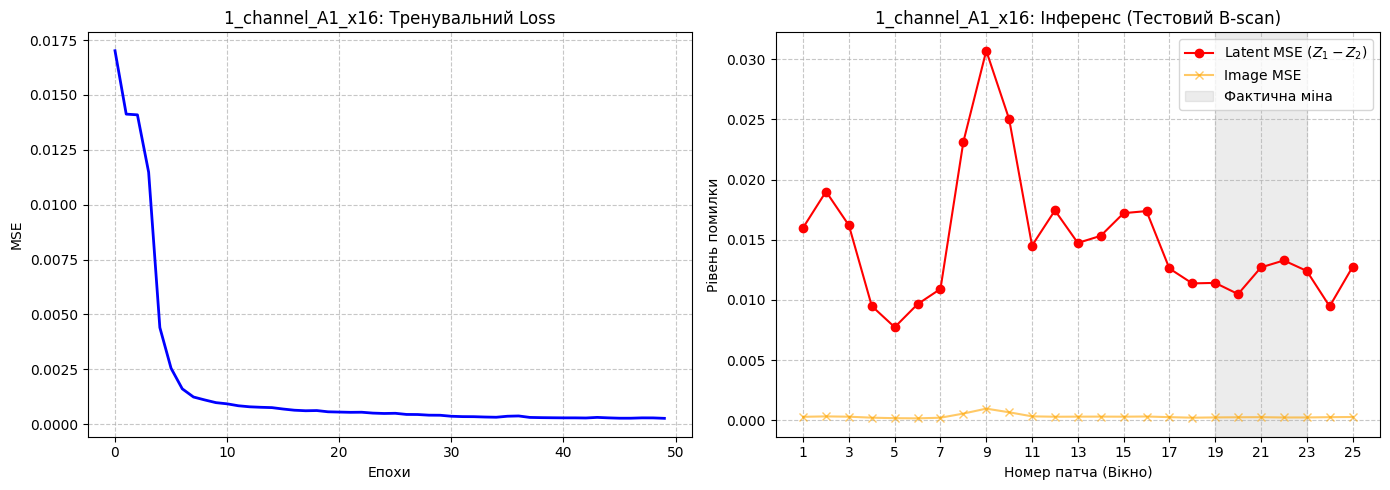

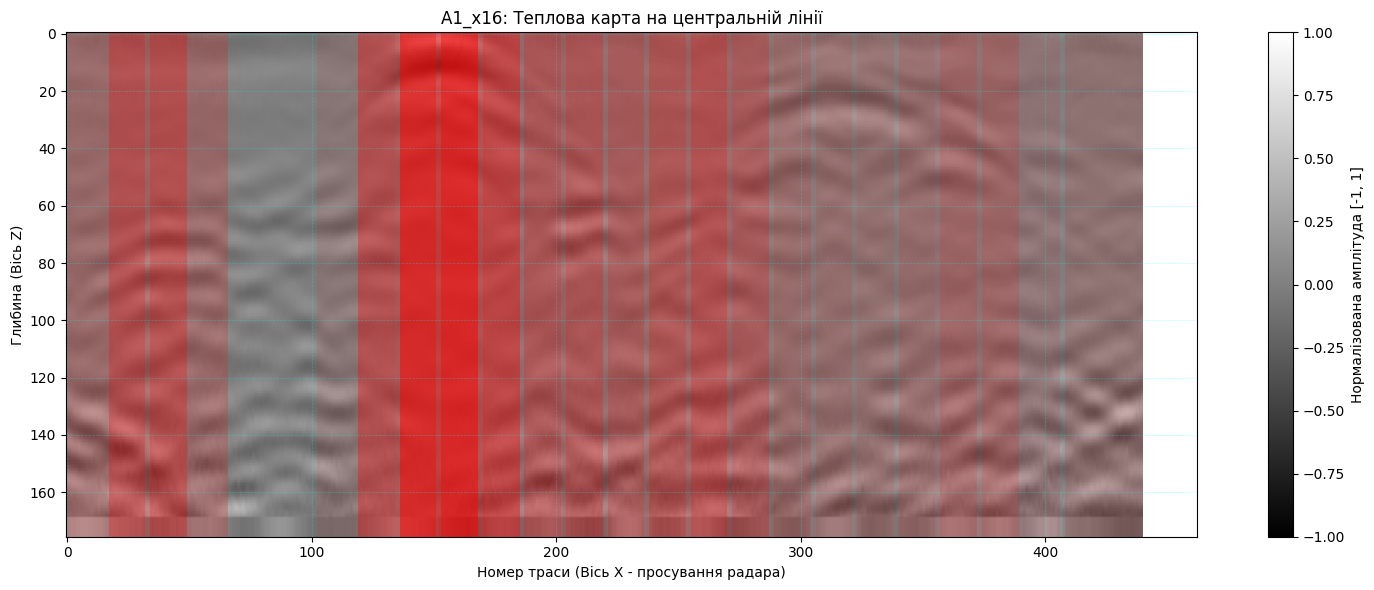

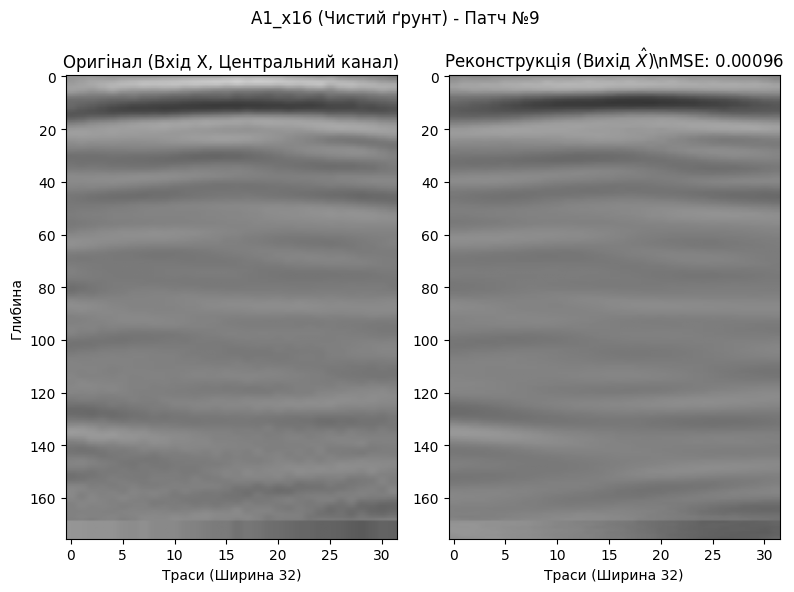

In [47]:
run_evaluation_pipeline(model_a1, 'A1_x16', CHANNEL_TYPE, test_loader, test_dataset, test_tensor, history_a1, device, criterion_mse)

### A2 (x32)

In [37]:
model_a2 = AutoencoderA2(in_channels=1, out_channels=1)
model_a2, hist_a2 = train_autoencoder(model_a2, train_loader, epochs=50, lr=0.001, device=device)


=== ПОЧАТОК ТРЕНУВАННЯ: AutoencoderA2 ===
Епоха [01/50], Loss: 0.017058
Епоха [10/50], Loss: 0.003641
Епоха [20/50], Loss: 0.002333
Епоха [30/50], Loss: 0.002099
Епоха [40/50], Loss: 0.002030
Епоха [50/50], Loss: 0.002001



=== ІНФЕРЕНС ТА ВІЗУАЛІЗАЦІЯ: A2_x32 (1_channel) ===
Оброблено 25 патчів.
✅ Результати збережено: [1_channel -> A2_x32]


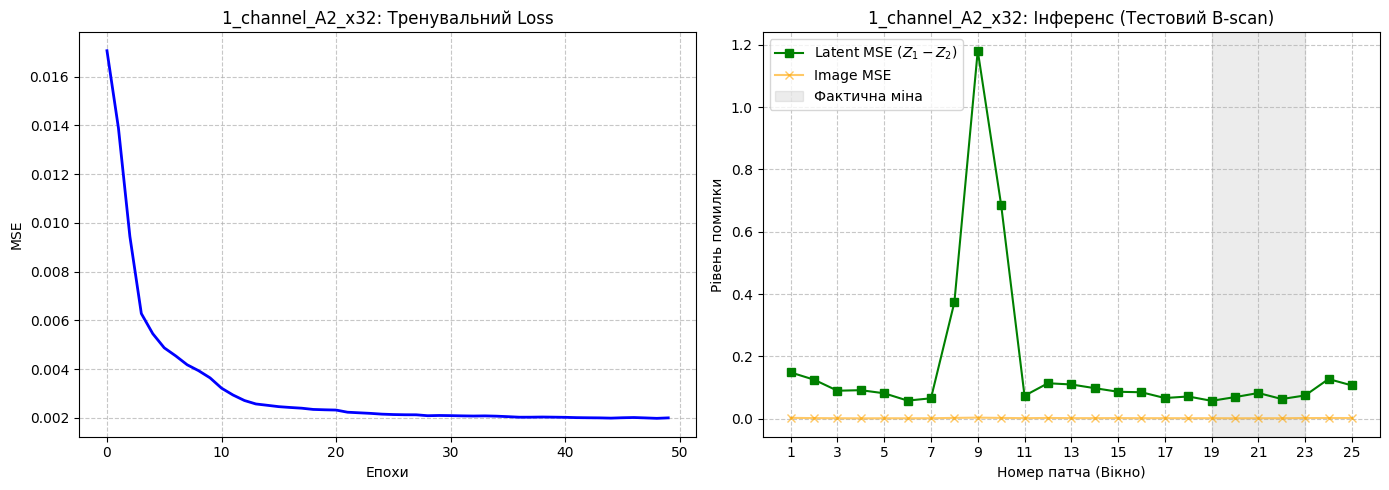

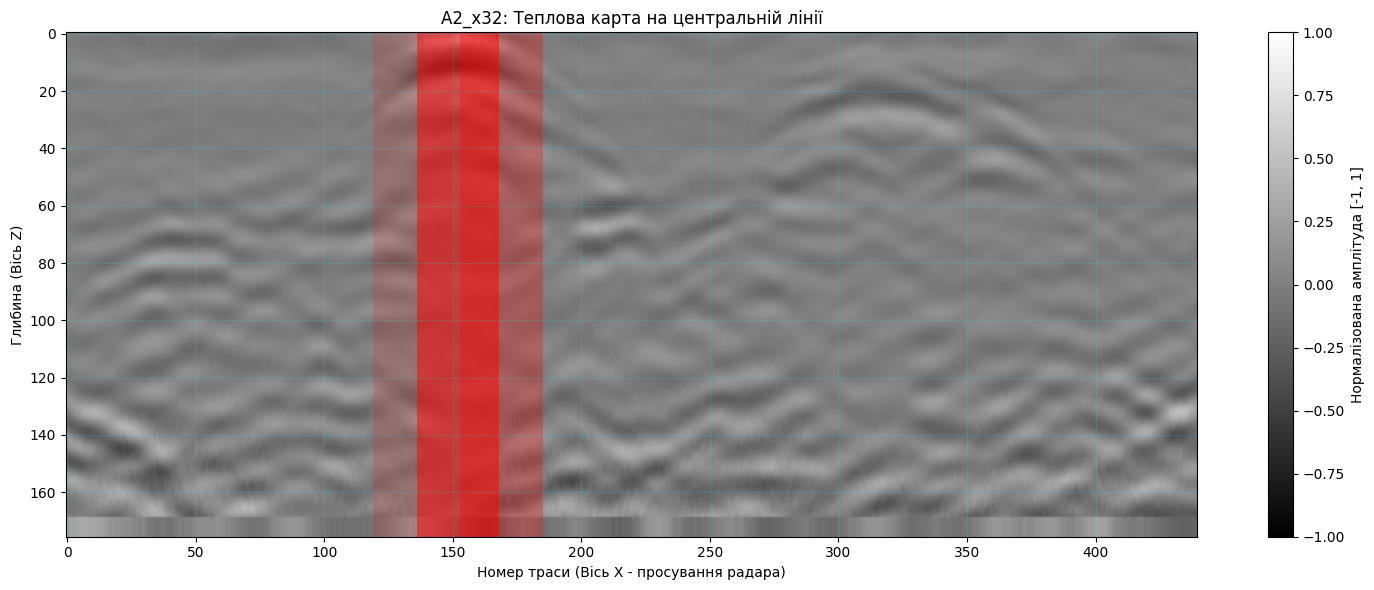

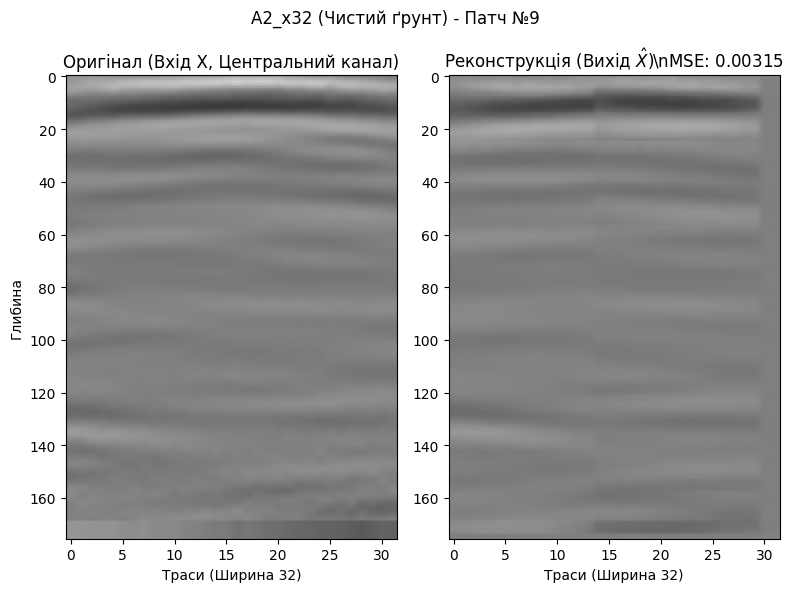

In [51]:
run_evaluation_pipeline(model_a2, 'A2_x32', CHANNEL_TYPE, test_loader, test_dataset, test_tensor, hist_a2, device, criterion_mse)

### Порівняння результатів

In [52]:
plot_comparison_from_json(RESULTS_FILE, channel_type=CHANNEL_TYPE)

⚠️ Для моделі A1_x16 немає даних test_latent_mse. Пропускаємо.
⚠️ Для моделі A2_x32 немає даних test_latent_mse. Пропускаємо.
⚠️ Для моделі A3_x64 немає даних test_latent_mse. Пропускаємо.
❌ Немає валідних даних для побудови графіка.


<Figure size 1500x700 with 0 Axes>